# Data visualization

Data visualization is the representation of data through use of common graphics, such as charts, plots, infographics and even animations. These visual displays of information communicate complex data relationships and data-driven insights in a way that is easy to understand.

We will focus on 2D visualization which means that there are two axes in each plot. 3D visualization is more complicated, but less clear than 2D visualization. However, many datasets have more than 3 features(columns). It is interesting to visualize high-dimensional data.

## Learning Objectives:

After this lecture, we will

- review `matplotlib` for data visulization
- be able to use `seaborn` for data visualization
- be able to identify the differences between `matplotlib` and `seaborn`

## Seaborn

In PIC16A course, you may have learned matplotlib, which is one python module for data visualization. In PIC16B, we will introduce another library **Seaborn, which is built on the roof of Matplotlib and is considered as a superset of the Matplotlib library.** Both act as the backbone of data visualization through Python.

You may also check ([seaborn official website](https://seaborn.pydata.org)) for more details.

## Differences between matplotlib and seaborn


What are the differences between Matplotlib and Seaborn? A detailed comparison from GeeksforGeeks can be found [here]( https://www.geeksforgeeks.org/difference-between-matplotlib-vs-seaborn/).

In our lecture, we will see the following:

1. **Level of abstraction.** You control everything when using matplotlib, while seaborn has automatic defaults (themes, colors, aggregation).

2. **Statistics.** Seaborn can compute: means, confidence intervals, and distributions.

In [1]:
# import seaborn module
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Example 1: Histogram for Different Groups

A histogram is a chart that plots the distribution of a numeric variable's values as a series of bars. Each bar typically covers a range of numeric values called a bin or class; a bar's height indicates the frequency of data points with a value within the corresponding bin.

In [2]:
# load dataset
penguins = sns.load_dataset("penguins")
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


<AxesSubplot:xlabel='flipper_length_mm', ylabel='Count'>

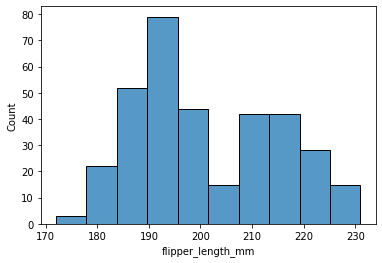

In [4]:
# histogram for "flipper_length_mm"
sns.histplot(data=penguins, x="flipper_length_mm")

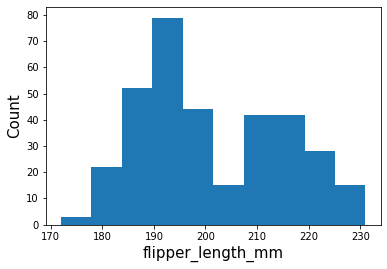

In [8]:
# matplotlib
plt.hist(penguins["flipper_length_mm"])
plt.xlabel("flipper_length_mm", size=15)
plt.ylabel("Count",size=15)
plt.show()

<AxesSubplot:xlabel='flipper_length_mm', ylabel='Count'>

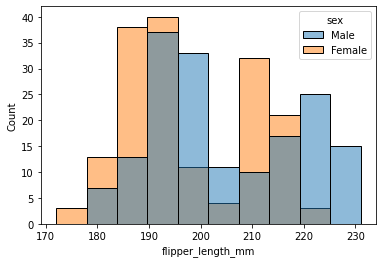

In [9]:
# Histogram for different groups:
sns.histplot(data=penguins, x="flipper_length_mm", hue="sex")

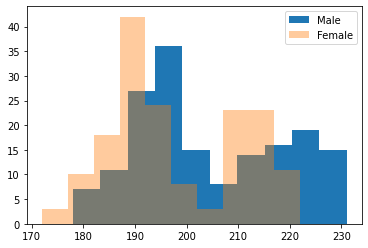

In [11]:
# Matplotlib:
df1 = penguins[penguins["sex"] == 'Male']
df2 = penguins[penguins["sex"] == 'Female']

plt.hist(df1["flipper_length_mm"], label='Male' )
plt.hist(df2["flipper_length_mm"], label='Female', alpha=0.4)
plt.legend()

# Example 2: Line Plot

#### Seaborn can show means and confidence intervals

In [12]:
# load dataset
flights = sns.load_dataset("flights")
flights

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121
...,...,...,...
139,1960,Aug,606
140,1960,Sep,508
141,1960,Oct,461
142,1960,Nov,390


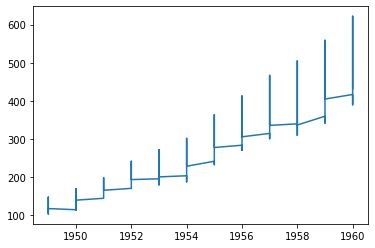

In [13]:
# matplotlib
plt.plot(flights['year'], flights['passengers'])

`plt.plot` connects given data points.

Now, we are ready to show that Seaborn line plot command (`seaborn.lineplot`) works in a different way. Specifically, if the input $x$ has repeated values, then the y-axis will be aggregated over repeated values by **showing the average and the 95% confidence interval**. If there is no repeated values over the x-axis, then it reduces to simple line plot.

P.S. A 95% confidence interval is often interpreted as indicating a range within which we can be 95% certain that the true effect lies.

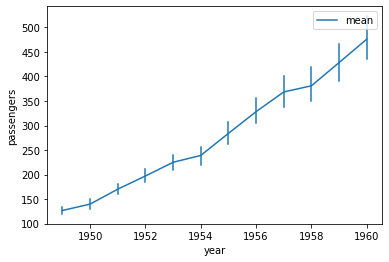

In [31]:
sns.lineplot(data=flights, x="year", y="passengers", label='mean', err_style='bars')
plt.legend()

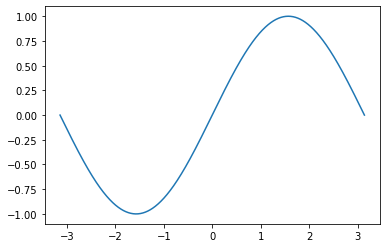

In [21]:
x = np.linspace(-np.pi,np.pi,1000)
y = np.sin(x)

plt.plot(x,y)

Producing the same plot using matplotlib is doable, but we should compute the average and standard deviation on our own.

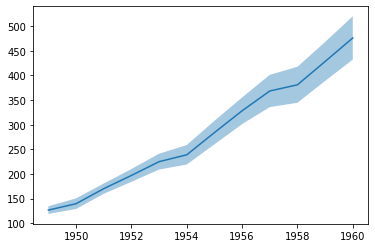

In [26]:
# compute mean and standard deviation
mean = flights.groupby('year').mean()
std = flights.groupby('year').std()

# compute upper and lower bounds
upper = mean + 1.96 * std / np.sqrt(len(mean))
lower = mean - 1.96 * std / np.sqrt(len(mean))

# visualize
plt.plot(mean.index, mean)
plt.fill_between(mean.index, upper['passengers'], lower['passengers'], alpha=0.4)

In [29]:
flights[['year','passengers']].groupby('year').mean()

,passengers
year,
1949,126.666667
1950,139.666667
1951,170.166667
1952,197.000000
1953,225.000000
1954,238.916667
1955,284.000000
1956,328.250000
1957,368.416667


Plotting average values and standard deviations are essential in research papers, see the following examples:

- [paper1](https://arxiv.org/pdf/2311.15845)
- [paper2](https://arxiv.org/pdf/2010.02681)

# Pairplot

A pair plot, also known as a scatterplot matrix, is a matrix of graphs that enables the visualization of the relationship between each pair of variables in a dataset. It combines both histogram and scatter plots, providing a unique overview of the dataset's distributions and correlations.

In [32]:
# load data set
iris = sns.load_dataset('iris')
iris 

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


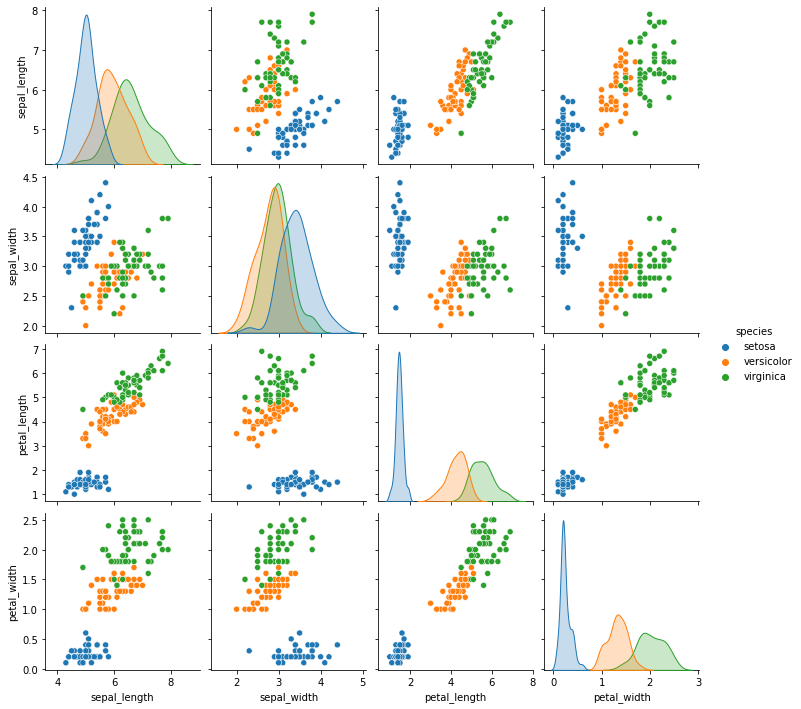

In [34]:
# Basic correlogram
sns.pairplot(iris, hue='species')

## Correlation matrix

Correlation is a statistical measure that expresses the extent to which two variables are linearly related (meaning they change together at a constant rate). It's a common tool for describing simple relationships without making a statement about cause and effect.

A correlation matrix is a statistical technique used to evaluate the relationship between two variables in a data set. The matrix is a table in which every cell contains a correlation coefficient, where 1 is considered a strong relationship between variables, 0 a neutral relationship and -1 a not strong relationship

In [23]:
# Compute the correlation matrix


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


We can use heatmap, which plot rectangular data as a color-encoded matrix, to visualize correlation matrix.

<AxesSubplot:>

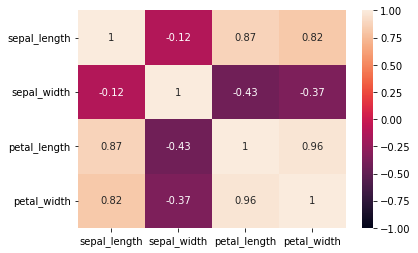

In [24]:
# Draw the heatmap with the mask and correct aspect ratio


How do we compute correlation based on data samples? The mathematical formula is 

$$ \mathrm{corr}(X,Y) = \frac{(X-\mu_X)(Y-\mu_Y)}{\sigma_X \sigma_Y}, $$

where $\mu_X$, $\mu_Y$ are the means of $X$ and $Y$, and $\sigma_X$, $\sigma_Y$ are the standard deviations of $X$ and $Y$, respectively.

# Regplot and jointplot

Seaborn acts as an important tool in picturing Machine Learning Models. Let's consider the linear regression model, which is a simple but powerful machine learning model. We can use one line command to visualize data samples and regression line.

Later, we will explain the linear regression model in detail. Here, we only want to show that we can visualize machine learning models easily using Seaborn.

<AxesSubplot:xlabel='total_bill', ylabel='tip'>

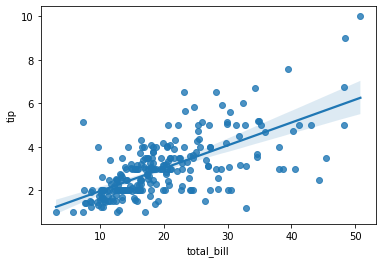

In [36]:
# load tips dataset
tips = sns.load_dataset("tips")
# use regplot to visualize data points and regression line
sns.regplot(data=tips,x='total_bill', y='tip')

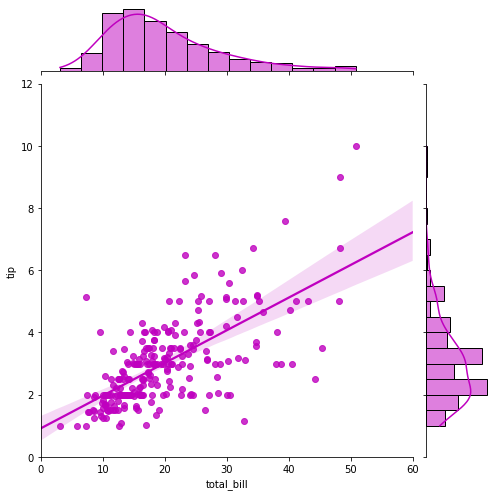